# Petri Net version of the simple slot machine example

This notebook shows a petri-net implementation of the "simple slot machine" example. The goal is to have a simple and clear implementation, which is why it is coded without use of existing petri-net python software packages. In further versions of this work, the examples shown below could be compared to those from existing packages such as [SNAKES](https://snakes.ibisc.univ-evry.fr), [SNAKES on GitHub](https://github.com/fpom/snakes)

The slot machine example is shown below:

<p align="center">
<img src="images_notebook/petri_net_2.png" width="400">
</p>

The code below implements the slot machine shown in the "Another Introduction to GTS". The main idea behing the implementation is to encode the state of the system as a vector of 3 states that reflect the 3 places on the petri-net shown above: the first place (top) is the first vector component, the second component is the place for the "left reel" and finally the 3 component is the "right reel". The symbols on the slot machine can be directly read from the 2nd and 3rd components of the state vector. Below is a reminder of how the petri-net implementation maps to the states of the slot-machine:

<p align="center">
<img src="images_notebook/petri_net_states.png" width="400">
</p>

The petri-net is implemented in python below. Then there is testing, and the simulation is at the end of the notebook.

In [1]:
import random as rand

def t_0(state):
    state[0] = 1 # the zeroth transition is fired at every time-step supplies the alpha place with a token
    return state

def t_1(state):
    state[0] -= 1 # the first transition takes a token from the alpha place ...
    state[1] += 1 # ... and transfers it to the x-place (first reel)
    return state

def t_2(state):
    state[0] -= 1 # the second transition takes a token from the alpha place ...
    state[2] += 1 # ... and transfers it to the y-place (second reel)
    return state

def t_3(state): 
    state[0] -= 1 # the 3rd transition takes a token from the alpha place but does not increment any other places
    return state

def t_4(state): 
    state[1] = 0 # the 4th transition depleats the x-place (first reel) if a 3rd token arrives
    return state

def t_5(state): 
    state[2] = 0 # the 5th transition depleats the y-place (first reel) if a 3rd token arrives
    return state

def alpha(state):
    if state[0] == 1:   # if the alpha place has a token, one of the three next transitions is fired with equal probability:
        x = rand.uniform(0.0, 1.0)  # uniform between 0 and 1
        if 0 <= x < 1/3:
            state = t_1(state)
            return state
        elif 1/3 <= x < 2/3:
            state = t_2(state)
            return state
        elif 2/3 <= x <= 1:
            state = t_3(state)
            return state
        
def X(state):
    if state[1] == 3:   # if the x-place has 3 tokens, it returns to 0 tokens:
        state = t_4(state)
    return state

def Y(state):
    if state[2] == 3:   # if the x-place has 3 tokens, it returns to 0 tokens:
        state = t_5(state)
    return state

def slot_machine(state):
    state = t_0(state) # this transformation is ok as long as all the items in the state vector are changed independently. Otherwise we would work with updating the states independently.
    state = alpha(state)
    state = X(state)
    state = Y(state)
    return state

## Testing

The following cells are used to test the implementation of the slot-machine example above. The test is described in the comments of each cell.

In [ ]:
# Timestepping
'''
This test looks at how the state vector evolves at each time step. Things to look out for:
1. the first state should always be zero
2. From the previous state vector, the next state needs to be incremented by 1.
3. The symbols should always be an integer between 0 and 2.
'''
timestep    = 0
T           = 10
state       = [0, 0, 0]
while timestep < T:
    state = t_0(state) # this transformation is ok as long as all the items in the state vector are changed independently. Otherwise we would work with updating the states independently.
    state = alpha(state)
    state = X(state)
    state = Y(state)

    print(f"t = {timestep:3d}, state = {state}")
    timestep += 1


t =   0, state = [0, 1, 0]
t =   1, state = [0, 1, 1]
t =   2, state = [0, 1, 1]
t =   3, state = [0, 1, 1]
t =   4, state = [0, 1, 2]
t =   5, state = [0, 2, 2]
t =   6, state = [0, 0, 2]
t =   7, state = [0, 0, 0]
t =   8, state = [0, 0, 0]
t =   9, state = [0, 0, 1]


In [10]:
# Stress testing
'''This looks at whether one of the states goes out of the 0,1,2 range.'''

def stress_test(T_max):
    timestep    = 0
    state       = [0, 0, 0]
    while timestep < T_max:
        state = t_0(state) # this transformation is ok as long as all the items in the state vector are changed independently. Otherwise we would work with updating the states independently.
        state = alpha(state)
        state = X(state)
        state = Y(state)

        if any(v > 2 for v in state):
            raise ValueError(f"State contains value > 2 at t={timestep}: {state}")
        timestep += 1

    print("test successful.")

stress_test(100)

test successful.


## Simulation

This section contains the functions used for the simulation. The goal of the simulation is to see whether "win rate" converges to 1/3, as the other probability frameworks predict.

In [ ]:
# This function counts the number of "wins"
def cumulative_matches(max_timestep: int):
    counts = []
    count = 0
    state = [0, 0, 0]
    for t in range(max_timestep + 1):
        state = slot_machine(state)  # your own function
        if state[1] == state[2]:
            count += 1
        counts.append(count)
    return counts

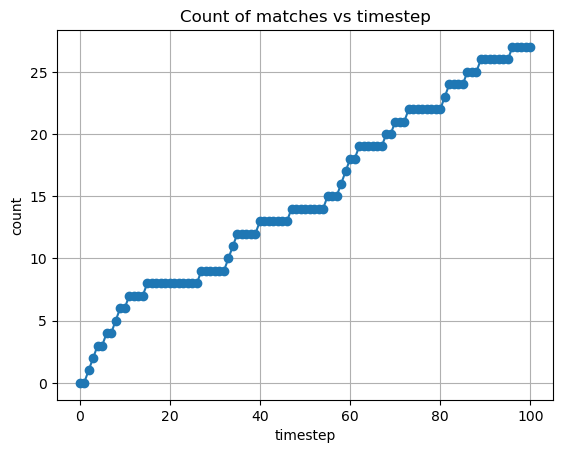

In [ ]:
# This cell is a test of the plotting function (make sure that the dots increase, never decrease with iincreasing iterations)
import matplotlib.pyplot as plt

max_timestep    = 100
counts          = cumulative_matches(max_timestep)
timesteps       = range(max_timestep + 1)

plt.figure()
plt.plot(timesteps, counts, marker="o")
plt.xlabel("timestep")
plt.ylabel("count")
plt.title("Count of matches vs timestep")
plt.grid(True)
plt.show()

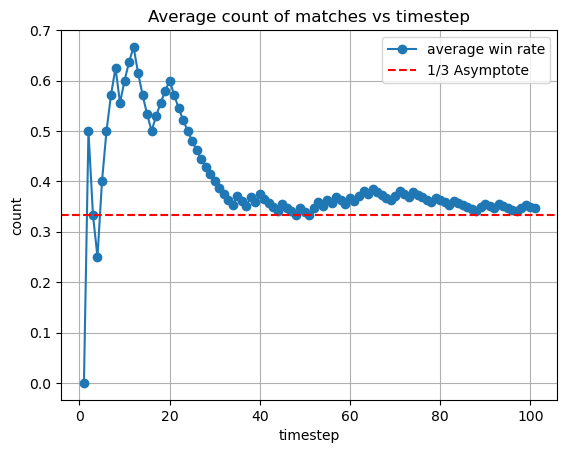

In [ ]:
# Plotting the "win" rate vs the timestep. This value should converge to 1/3.
max_timestep    = 100
counts          = cumulative_matches(max_timestep)
timesteps       = range(1, max_timestep+2)

average_counts = [x/y  for x, y in zip(counts, timesteps)]

plt.figure()
plt.plot(timesteps, average_counts, marker="o", label="average win rate")
plt.axhline(y=1/3, color="red", linestyle="--", label="1/3 Asymptote")
plt.xlabel("timestep")
plt.ylabel("count")
plt.title("Average count of matches vs timestep")
plt.grid(True)
plt.legend()
plt.savefig("convergence_petri.png", dpi=300, bbox_inches="tight")
plt.show()

# Conclusion
When playing with the cell above, one sees that convergence to 1/3 does not always happen within a 100 steps, but it does for larger numbers: it depends on the random number generation. It is however more convienient to "pick" a plot that shows convergence within 100 steps so that the behaviour for few time-steps is visible.